# 1. Breast Cancer Dataset

 EVALUACIÓN: BREAST CANCER DATASET
    Modelo  K-Fold Acc Promedio  K-Fold Std  LOO Acc Promedio
       LDA             0.954323    0.017855          0.957821
K-NN (k=5)             0.963001    0.025679          0.970123


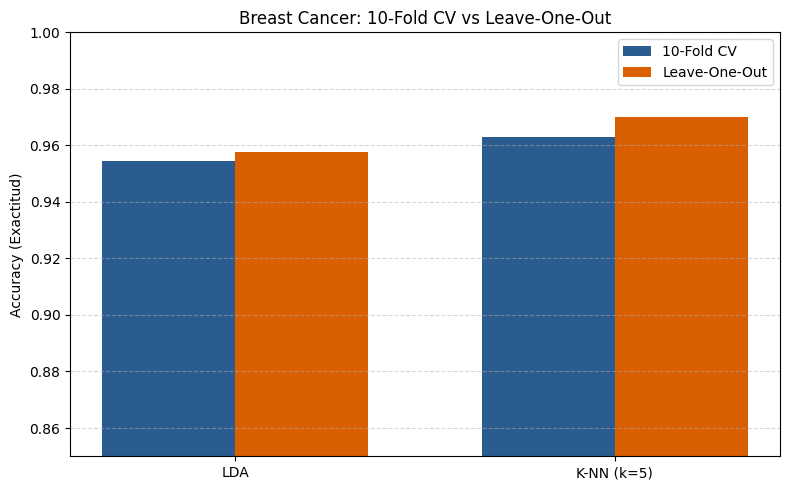

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 1. Cargar Datos
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Definir Modelos (con escalado previo)
models = {
    'LDA': make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    'K-NN (k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
}

# 3. Esquemas de Validación
cv_kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_loo = LeaveOneOut()

results = []

for name, model in models.items():
    # K-Fold (10 Folds)
    scores_kfold = cross_val_score(model, X, y, cv=cv_kfold, scoring='accuracy')

    # Leave-One-Out (LOO)
    scores_loo = cross_val_score(model, X, y, cv=cv_loo, scoring='accuracy')

    results.append({
        'Modelo': name,
        'K-Fold Acc Promedio': scores_kfold.mean(),
        'K-Fold Std': scores_kfold.std(),
        'LOO Acc Promedio': scores_loo.mean()
    })

df_res = pd.DataFrame(results)
print("="*65)
print(" EVALUACIÓN: BREAST CANCER DATASET")
print("="*65)
print(df_res.to_string(index=False))

# 4. Gráfica Comparativa
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, df_res['K-Fold Acc Promedio'], width, label='10-Fold CV', color='#2b5c8f')
ax.bar(x + width/2, df_res['LOO Acc Promedio'], width, label='Leave-One-Out', color='#d95f02')

ax.set_ylabel('Accuracy (Exactitud)')
ax.set_title('Breast Cancer: 10-Fold CV vs Leave-One-Out')
ax.set_xticks(x)
ax.set_xticklabels(df_res['Modelo'])
ax.set_ylim(0.85, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Wine Dataset

 EVALUACIÓN: WINE DATASET
           Modelo  5-Fold Acc  5-Fold Std  LOO Acc
              LDA    0.988730    0.013805 0.988764
       K-NN (k=3)    0.955079    0.013688 0.955056
Árbol de Decisión    0.887619    0.046507 0.887640


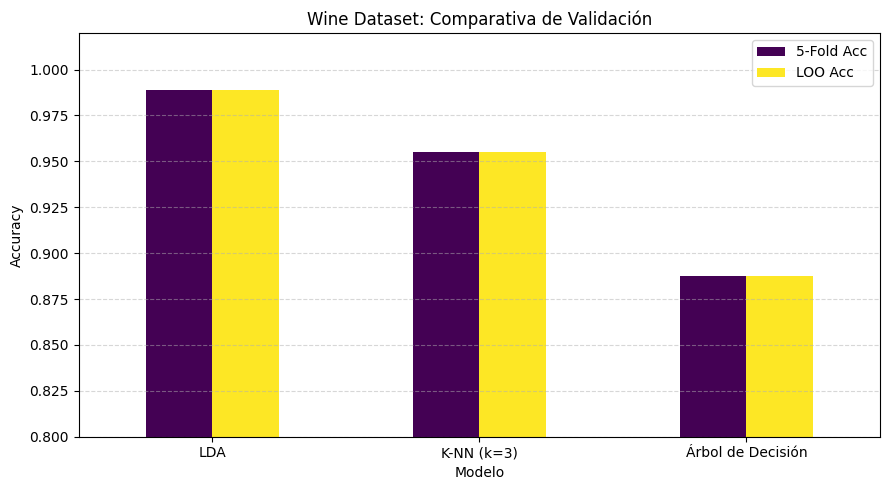

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1. Cargar Datos
wine = load_wine()
X, y = wine.data, wine.target

# 2. Definir Clasificadores
models = {
    'LDA': make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    'K-NN (k=3)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3)),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=3, random_state=42)
}

# 3. Validación K-Fold y LOO
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_loo = LeaveOneOut()

results = []

for name, model in models.items():
    kf_scores = cross_val_score(model, X, y, cv=cv_kfold, scoring='accuracy')
    loo_scores = cross_val_score(model, X, y, cv=cv_loo, scoring='accuracy')

    results.append({
        'Modelo': name,
        '5-Fold Acc': kf_scores.mean(),
        '5-Fold Std': kf_scores.std(),
        'LOO Acc': loo_scores.mean()
    })

df_wine = pd.DataFrame(results)
print("="*60)
print(" EVALUACIÓN: WINE DATASET")
print("="*60)
print(df_wine.to_string(index=False))

# 4. Gráfica Comparativa
df_wine.plot(x='Modelo', y=['5-Fold Acc', 'LOO Acc'], kind='bar', figsize=(9, 5), colormap='viridis')
plt.title('Wine Dataset: Comparativa de Validación')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.02)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. MNIST Digits (Dígitos Manuscritos)

 EVALUACIÓN: MNIST DIGITS (Muestra 500 datos)

--- K-NN (k=3) ---
Accuracy 5-Fold: 0.9800 | Accuracy LOO: 0.9860

--- Árbol de Decisión ---
Accuracy 5-Fold: 0.6940 | Accuracy LOO: 0.7580


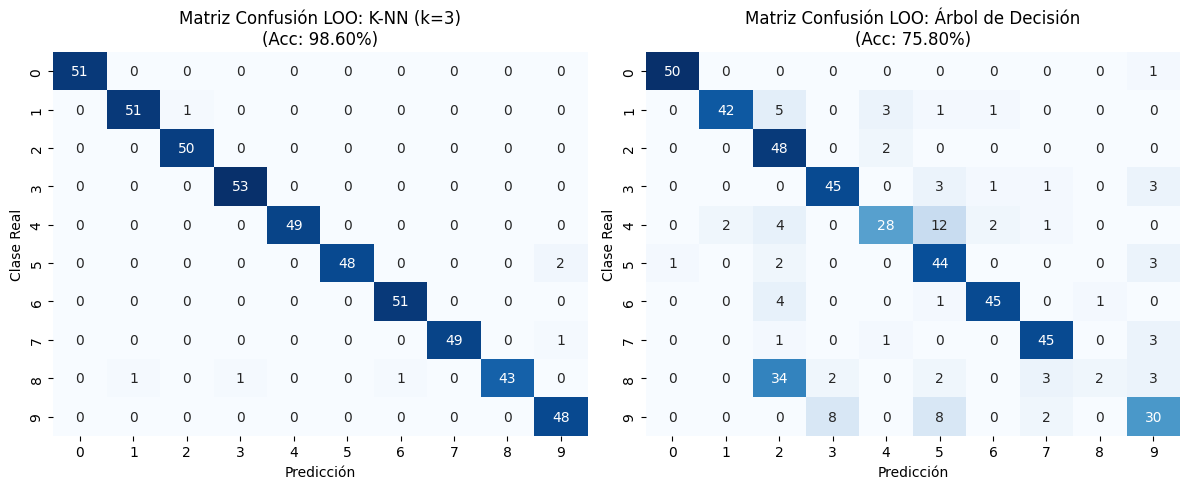

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns

# 1. Cargar Datos (Muestra optimizada para LOO)
digits = load_digits()
X, y = digits.data[:500], digits.target[:500]

# 2. Modelos a Comparar
models = {
    'K-NN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=5, random_state=42)
}

cv_kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_loo = LeaveOneOut()

print("="*65)
print(" EVALUACIÓN: MNIST DIGITS (Muestra 500 datos)")
print("="*65)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(models.items()):
    # Predicción de Leave-One-Out para la Matriz de Confusión
    y_pred_loo = cross_val_predict(model, X, y, cv=cv_loo)
    acc_loo = accuracy_score(y, y_pred_loo)

    # Predicción K-Fold
    y_pred_kf = cross_val_predict(model, X, y, cv=cv_kf)
    acc_kf = accuracy_score(y, y_pred_kf)

    print(f"\n--- {name} ---")
    print(f"Accuracy 5-Fold: {acc_kf:.4f} | Accuracy LOO: {acc_loo:.4f}")

    # Graficar Matriz de Confusión de LOO
    cm = confusion_matrix(y, y_pred_loo)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Matriz Confusión LOO: {name}\n(Acc: {acc_loo:.2%})')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Clase Real')

plt.tight_layout()
plt.show()

# 4. MNIST Fashion (Prendas de Vestir)

Cargando Fashion-MNIST...
Evaluando K-NN (k=5)...
Evaluando Árbol de Decisión...

 RESULTADOS: MNIST FASHION
           Modelo  5-Fold Acc  LOO Acc
       K-NN (k=5)      0.6725   0.6725
Árbol de Decisión      0.5700   0.5400


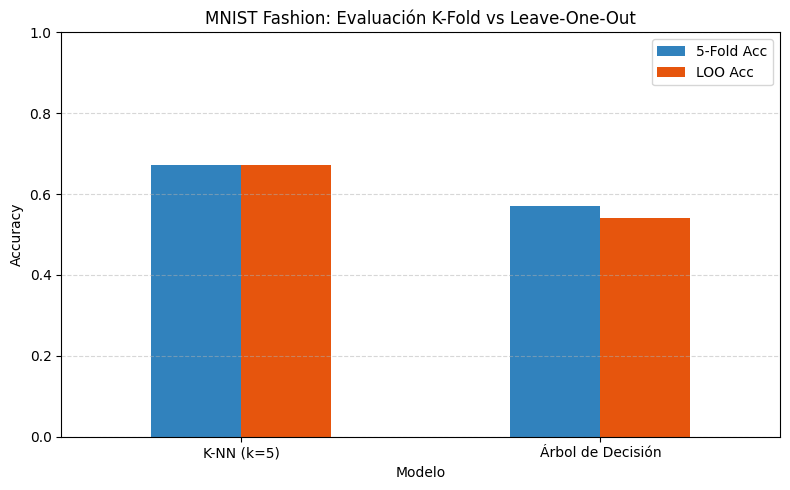

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Cargar conjunto de datos Fashion-MNIST
print("Cargando Fashion-MNIST...")
fashion = fetch_openml(name='Fashion-MNIST', version=1, as_frame=False, parser='auto')

# Submuestreo estratificado para que Leave-One-Out se ejecute rápidamente (400 muestras)
np.random.seed(42)
indices = np.random.choice(len(fashion.data), size=400, replace=False)
X, y = fashion.data[indices] / 255.0, fashion.target[indices].astype(int)

# 2. Clasificadores
models = {
    'K-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=6, random_state=42)
}

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_loo = LeaveOneOut()

results = []

for name, model in models.items():
    print(f"Evaluando {name}...")
    scores_kf = cross_val_score(model, X, y, cv=cv_kfold, scoring='accuracy')
    scores_loo = cross_val_score(model, X, y, cv=cv_loo, scoring='accuracy')

    results.append({
        'Modelo': name,
        '5-Fold Acc': scores_kf.mean(),
        'LOO Acc': scores_loo.mean()
    })

df_fashion = pd.DataFrame(results)

# Corregida la línea divisoria del print:
print("\n" + "="*60)
print(" RESULTADOS: MNIST FASHION")
print("="*60)
print(df_fashion.to_string(index=False))

# 3. Graficar Comparativa
fig, ax = plt.subplots(figsize=(8, 5))
df_fashion.plot(x='Modelo', y=['5-Fold Acc', 'LOO Acc'], kind='bar', ax=ax, color=['#3182bd', '#e6550d'])
ax.set_title('MNIST Fashion: Evaluación K-Fold vs Leave-One-Out')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()